# AG News Dataset for Text Classification with RNN and LSTM

## Overview
The **AG News Dataset** is a collection of over 120,000 news articles categorized into four distinct classes: *World*, *Sports*, *Business*, and *Science/Technology*. Each article has a title and a description, providing rich contextual data for classification tasks. This dataset is widely used for text classification benchmarks and is suitable for training deep learning models, especially for natural language processing tasks.

## Objective
The primary goal of this project is to classify news articles into their respective categories using a **Recurrent Neural Network (RNN)** with **Long Short-Term Memory (LSTM)** cells. LSTMs are chosen due to their effectiveness in handling sequential data and their capability to capture long-term dependencies in text sequences.

## Dataset Details
- **Total Samples**: 120,000 articles (training and test sets combined)
- **Classes**: 4 (World, Sports, Business, Science/Technology)
- **Features**:
- **Title**: Short headline of the news article.
- **Description**: Brief summary of the article content.

### Import Libraries for Data Handling, Visualization, and Model Creation
This section imports essential libraries for data processing, visualization, and building a neural network model for text classification. **Pandas** and **NumPy** are used for data manipulation. **Matplotlib** and **Seaborn** provide tools for data visualization. **Keras** modules support text preprocessing, such as tokenization and padding, and model building with layers like Embedding and LSTM. **Scikit-learn** aids in encoding labels and calculating the F1 score, while **KaggleHub** enables direct dataset access. Finally, **os** and **random** are used for system operations and randomness, respectively.

In [59]:
# Import Pandas and NumPy for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import random for random operations
import random

# Import Keras utilities for text preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer  # Text tokenization
from tensorflow.keras.preprocessing.sequence import pad_sequences  # Padding sequences

# Import Keras modules for model creation
from tensorflow.keras.models import Sequential  # Sequential model structure
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout  # Model layers

# Import Adam optimizer from Keras
from tensorflow.keras.optimizers import Adam

# Import scikit-learn tools for label encoding and evaluation
from sklearn.preprocessing import LabelEncoder  # Label encoding for categorical data
from sklearn.metrics import f1_score  # F1 score for model evaluation

# Import KaggleHub for direct access to Kaggle datasets
import kagglehub

# Import os for system operations
import os

### Download Dataset Using KaggleHub
This section demonstrates how to download the latest version of the **AG News Classification Dataset** using the **KaggleHub** library. The `dataset_download` function fetches the dataset, and the path to the downloaded files is printed for further use. This approach simplifies the process of accessing datasets directly from Kaggle within your environment.

In [15]:
# Download the latest version of the AG News dataset from KaggleHub
path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")

# Print the path to the dataset files for reference
print(f"Path to dataset files: {path}")

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\amananandrai\ag-news-classification-dataset\versions\2


In [16]:
# Define the base directory for the "AG News" dataset
BASE_DIR = "C:/Users/USER/.cache/kagglehub/datasets/amananandrai/ag-news-classification-dataset/versions/2"

### Define Dataset Directory and Load Data
This section defines the **base directory** where the **AG News Classification Dataset** is stored, specifically under the KaggleHub cache directory. The `train.csv` and `test.csv` files are then loaded into **Pandas DataFrames** for further analysis and model training. The `train_df` DataFrame is displayed as the output, providing a preview of the training data.

In [17]:
# Load the training data into a Pandas DataFrame
train_df = pd.read_csv(os.path.join(BASE_DIR, "train.csv"))

# Load the testing data into a Pandas DataFrame
test_df = pd.read_csv(os.path.join(BASE_DIR, "test.csv"))

# Display the training data
train_df.sample(20)

,Class Index,Title,Description
65695,2,"With One Life to Live, the Red Sox Want It Now",The Red Sox will either complete an amazing co...
99874,4,Three Big Music Labels Sign Up for Peer Impact...,Reuters - Three of the Big Four music labels\h...
71957,3,Mittal Family Forges \$17.8 Bln Steel Deal,AMSTERDAM/NEW YORK (Reuters) - Steel magnate ...
41656,4,Geek notes,"BENQ #39;S new digital music player line, the ..."
11369,2,"NL Wrap: Sosa Hits 568th Homer, Cubs Eclipse A...",NEW YORK (Reuters) - Sammy Sosa grabbed his 5...
57911,2,ROON AGENT MISLED COURT,THE trial of three men accused of blackmailing...
104521,1,"With ban imminent, Prince William joins fox hu...",AFP - Britain's Prince William went fox huntin...
26498,2,"AL Wrap: Ford, Radke Help Twins Sweep Tigers",NEW YORK (Reuters) - Lew Ford homered and dro...
11778,4,HP iPod launches today,The announcement will be made at a news confer...
1161,1,A Look at U.S. Military Deaths in Iraq (AP),"AP - As of Monday, Aug. 16, 935 U.S. service m..."


### Select Features and Labels from the Dataset
This section selects the **text descriptions** and **class labels** from the AG News dataset. The `Description` column is assigned to `X_train` and `X_test` as input features for training and testing. The `Class Index` column, representing the category labels, is assigned to `y_train` and `y_test` for supervised learning.

In [37]:
# Select the 'Description' column as input features for training and testing
X_train = train_df["Description"]
X_test = test_df["Description"]

# Select the 'Class Index' column as target labels for training and testing
y_train = train_df["Class Index"]
y_test = test_df["Class Index"]

### Visualize Data Distribution by Target Class
This section creates a **count plot** to visualize the distribution of samples across each target class in the training dataset. It provides a quick overview of how balanced or imbalanced the dataset is across different classes. The plot includes labels and a title for better clarity.

C:\Users\USER\AppData\Local\Temp\ipykernel_2304\1008597159.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class Index", data=train_df, palette="Set2")


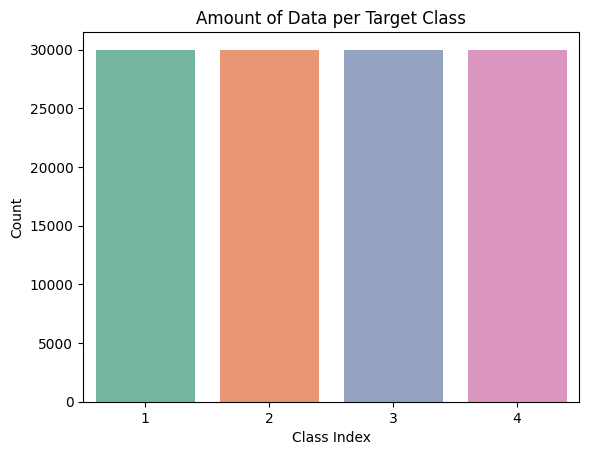

In [55]:
plt.figure()

# Create a count plot to show the number of samples per target class
sns.countplot(x="Class Index", data=train_df, palette="Set2")

# Set title and labels for clarity
plt.title("Amount of Data per Target Class")
plt.xlabel("Class Index")
plt.ylabel("Count")

# Display the plot
plt.show()

### Encode Target Labels
This section encodes the target labels for training and testing using **LabelEncoder**. By transforming categorical class labels into numerical values, this step prepares the labels for compatibility with machine learning algorithms.

In [38]:
# Initialize the LabelEncoder for label encoding
label_encoder = LabelEncoder()

# Fit and transform the training labels, and transform the test labels
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

### Tokenize and Pad Text Sequences
This section tokenizes and pads the text sequences to prepare them for model input. Using **Tokenizer**, each word in the training dataset is converted into an integer index based on frequency, up to a maximum vocabulary size defined by `MAX_WORDS`. The text sequences are then padded to a uniform length (`MAX_LEN`) to ensure compatibility with the neural network model.

In [39]:
# Set maximum vocabulary size and sequence length
MAX_WORDS = 100000
MAX_LEN = 200

# Initialize the tokenizer with the maximum number of words
tokenizer = Tokenizer(num_words=MAX_WORDS)

# Fit the tokenizer on the training text data
tokenizer.fit_on_texts(X_train)

# Convert training and test text data to sequences of integer indices
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

# Pad the sequences to ensure uniform input length
X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

### Define the Neural Network Model
This section defines the neural network model using a **Sequential** architecture, specifically tailored for text classification. The model includes:
- An **Embedding** layer that converts word indices into dense vectors of fixed size (`EMBEDDING_DIM`).
- An **LSTM** layer with 128 units to capture sequential dependencies in the data.
- A **Dense** layer with 128 units and ReLU activation for feature extraction.
- A **Dropout** layer to reduce overfitting by randomly setting 50% of the input units to zero.
- A final **Dense** layer with 4 units and softmax activation to output class probabilities for each of the four categories.
The model summary is printed to display the architecture and layer details.

In [42]:
# Set embedding dimension and calculate vocabulary size
EMBEDDING_DIM = 100
vocab_size = len(tokenizer.word_index) + 1  # Include an extra index for padding

# Define the sequential model architecture
model = Sequential([
    # Embedding layer for converting words to dense vectors
    Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN),
    
    # LSTM layer to capture sequence patterns
    LSTM(128),
    
    # Dense layer with ReLU activation for feature extraction
    Dense(128, activation='relu'),
    
    # Dropout layer to reduce overfitting
    Dropout(0.5),
    
    # Output layer with softmax activation for multi-class classification
    Dense(4, activation='softmax')
])

# Display the model summary
model.summary()

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### Compile and Train the Model
In this section, the model is compiled and trained. The **Adam** optimizer with a learning rate of 0.0001 is used to optimize the model, and **sparse categorical cross-entropy** is chosen as the loss function for multi-class classification. The model’s performance will be evaluated based on **accuracy**. Training is performed for 5 epochs with a batch size of 64 and a 10% validation split to monitor performance on unseen data. An additional learning rate scheduler could be considered to further improve training results.

In [44]:
# Initialize the Adam optimizer with a low learning rate
optim = Adam(learning_rate=0.0001)

# Compile the model with specified optimizer, loss function, and accuracy metric
model.compile(optimizer=optim, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model with training data and validation split
# A learning rate scheduler could further improve results
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 199s 117ms/step - accuracy: 0.5625 - loss: 0.9570 - val_accuracy: 0.8755 - val_loss: 0.3504
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 222s 132ms/step - accuracy: 0.9037 - loss: 0.3045 - val_accuracy: 0.8893 - val_loss: 0.3132
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 200s 119ms/step - accuracy: 0.9263 - loss: 0.2400 - val_accuracy: 0.8905 - val_loss: 0.3175
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 192s 114ms/step - accuracy: 0.9386 - loss: 0.1978 - val_accuracy: 0.8892 - val_loss: 0.3165
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 192s 114ms/step - accuracy: 0.9492 - loss: 0.1677 - val_accuracy: 0.8854 - val_loss: 0.3365


### Evaluate the Model on Test Data
This section evaluates the model's performance on the test set using the `evaluate()` method. It calculates the **loss** and **accuracy** of the model on unseen data (test set). The accuracy is printed to 4 decimal places to assess the model's final performance.

In [ ]:
# Evaluate the model using the test data to compute loss and accuracy
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

# Print the test accuracy to assess the model's performance
print(f'Test accuracy: {accuracy:.4f}')

Test accuracy: 0.8979


### Generate Predictions and Evaluate F1 Score
This section generates predictions on the test data using the trained model. The predicted class probabilities are converted into class labels using `np.argmax()`. The **F1 score** is then calculated using the `f1_score` function from **scikit-learn**, with the **weighted average** to account for class imbalance. The weighted F1 score is printed to 4 decimal places to evaluate the model's classification performance.

In [ ]:
# Generate predictions on the test data
y_pred = model.predict(X_test)

# Convert the predicted probabilities into class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate the weighted F1 score to evaluate classification performance
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Print the weighted F1 score
print(f'Weighted F1 Score: {f1:.4f}')

238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
Weighted F1 Score: 0.8978


### Display Random Prediction Results
This section selects 20 random indices from the test set predictions and displays the results for each. For each randomly selected example, the predicted class label, actual class label, and predicted probabilities are printed. This allows for a more detailed inspection of the model's performance on individual test samples.

In [ ]:
# Select 20 random indices from the test set
random_indexes = random.sample(range(len(y_test)), 20)

# Display the results for each randomly selected example
for idx, i in enumerate(random_indexes, 1):
    # Print the predicted class, actual class, and predicted probabilities
    print(f"--- Example {idx} ---")
    print(f"Predicted class    : {y_pred_classes[i]}")
    print(f"Actual class       : {y_test[i]}")
    print(f"Predicted probs    : {y_pred[i]}")
    print("-" * 30)  # Separator for better readability

--- Example 1 ---
Predicted class    : 0
Actual class       : 0
Predicted probs    : [9.9750584e-01 4.9839605e-04 1.1711173e-03 8.2456291e-04]
------------------------------
--- Example 2 ---
Predicted class    : 1
Actual class       : 1
Predicted probs    : [4.4869789e-04 9.9954909e-01 2.1049207e-06 1.2508889e-07]
------------------------------
--- Example 3 ---
Predicted class    : 2
Actual class       : 2
Predicted probs    : [3.878894e-03 8.495256e-06 9.951261e-01 9.864091e-04]
------------------------------
--- Example 4 ---
Predicted class    : 0
Actual class       : 0
Predicted probs    : [9.8938352e-01 7.6287207e-03 2.5794234e-03 4.0831667e-04]
------------------------------
--- Example 5 ---
Predicted class    : 2
Actual class       : 2
Predicted probs    : [4.3252748e-03 8.0612044e-05 9.9536514e-01 2.2891113e-04]
------------------------------
--- Example 6 ---
Predicted class    : 2
Actual class       : 2
Predicted probs    : [2.7784193e-03 2.0321919e-05 5.5789948e-01 4.3930